# Milestone 10 Objective

Build the Bug Analysis Agent as a standalone agent first.

## Bug Analysis Agent Role

The Bug Analysis Agent reads API execution results, classifies failures and anomalies with deterministic rules, assigns severity, and writes concise recommendations.

## Why It Works Alone Before Integration

The agent is verified independently so it can safely analyze `api_result.json` artifacts before it is connected to the full LangGraph pipeline.

## Rule-Based Classification Strategy

- `environment_error` for unreachable targets or timeouts.
- `security_risk` for expected 401/403 responses that unexpectedly return 200.
- `application_bug` for HTTP 5xx or unexpected status codes.
- `skipped_or_not_executable` for unresolved dynamic endpoints.
- Severity is assigned from evidence only.

## Mini LangGraph Workflow

```text
START -> bug_analysis -> END
```

## State Contract

Reads from State: `api_results`, `api_result_path`, and `user_preferences`.

Writes to State: `bug_results`, `bug_result_path`, and `recommendations`.

## Safety Note

The agent does not call the target app, does not execute repository code, does not call LLM APIs, and does not expose tokens.

Target repository: https://github.com/Vitaee/DjangoRestAPI

## Part A - Fake API Result Analysis

In [1]:
from test_auto.agents.bug_analysis_agent import run_bug_analysis_agent_alone

fake_api_results = {
    'agent': 'api_testing',
    'status': 'partial',
    'summary': {
        'total_tests': 5,
        'passed': 1,
        'failed': 2,
        'skipped': 1,
        'errors': 1,
        'pass_rate': 20.0,
    },
    'tests': [
        {'id': 'API_001', 'name': 'list_todos', 'method': 'GET', 'endpoint': '/api/todos/', 'status': 'passed', 'expected_status': 200, 'actual_status': 200, 'duration_ms': 25.0, 'details': 'ok'},
        {'id': 'API_002', 'name': 'target_down', 'method': 'GET', 'endpoint': '/api/todos/', 'status': 'environment_error', 'expected_status': 200, 'actual_status': None, 'details': 'Connection refused'},
        {'id': 'API_003', 'name': 'auth_required', 'method': 'GET', 'endpoint': '/api/todos/', 'status': 'assertion_error', 'expected_status': 401, 'actual_status': 200, 'details': 'Expected 401, got 200.'},
        {'id': 'API_004', 'name': 'server_error', 'method': 'GET', 'endpoint': '/api/todos/', 'status': 'assertion_error', 'expected_status': 200, 'actual_status': 500, 'details': 'Expected 200, got 500.'},
        {'id': 'API_005', 'name': 'dynamic_detail', 'method': 'GET', 'endpoint': '/api/todos/<int:pk>/', 'status': 'skipped', 'expected_status': None, 'actual_status': None, 'details': 'Endpoint contains unresolved dynamic path parameters.'},
    ],
}

bug_result = run_bug_analysis_agent_alone(api_results=fake_api_results)
{
    'summary': bug_result['summary'],
    'bug_result_path': bug_result['bug_result_path'],
    'recommendations_count': len(bug_result['recommendations']),
}


{'summary': {'total_anomalies': 5,
  'high': 3,
  'medium': 1,
  'low': 0,
  'info': 1,
  'by_classification': {'application_bug': 2,
   'environment_error': 1,
   'security_risk': 1,
   'skipped_or_not_executable': 1}},
 'bug_result_path': 'results\\runs\\run_20260520T084143Z_dba0ba35\\bug_result.json',
 'recommendations_count': 4}

In [2]:
[
    {
        'id': item['id'],
        'classification': item['classification'],
        'severity': item['severity'],
        'type': item['type'],
        'title': item['title'],
    }
    for item in bug_result['bug_results']['anomalies']
]


[{'id': 'BUG_API_002',
  'classification': 'environment_error',
  'severity': 'medium',
  'type': 'target_unreachable',
  'title': 'API environment error for GET /api/todos/'},
 {'id': 'BUG_API_003',
  'classification': 'security_risk',
  'severity': 'high',
  'type': 'authorization_bypass',
  'title': 'Possible authorization bypass on GET /api/todos/'},
 {'id': 'BUG_API_004',
  'classification': 'application_bug',
  'severity': 'high',
  'type': 'server_error',
  'title': 'Server error from GET /api/todos/'},
 {'id': 'BUG_API_005',
  'classification': 'skipped_or_not_executable',
  'severity': 'info',
  'type': 'skipped_api_test',
  'title': 'API test skipped for GET /api/todos/<int:pk>/'},
 {'id': 'BUG_API_SUMMARY_001',
  'classification': 'application_bug',
  'severity': 'high',
  'type': 'low_api_pass_rate',
  'title': 'API pass rate is critically low (20.0%)'}]

In [3]:
bug_result['recommendations']

[{'priority': 'high',
  'title': 'Address application bug findings',
  'action': 'Inspect server logs and handler code for the endpoint returning HTTP 5xx.',
  'related_anomaly_ids': ['BUG_API_004', 'BUG_API_SUMMARY_001']},
 {'priority': 'high',
  'title': 'Address security risk findings',
  'action': 'Verify authentication and permission checks for this endpoint.',
  'related_anomaly_ids': ['BUG_API_003']},
 {'priority': 'medium',
  'title': 'Address environment error findings',
  'action': 'Verify that the target application is running and reachable at target_url before interpreting API failures.',
  'related_anomaly_ids': ['BUG_API_002']},
 {'priority': 'info',
  'title': 'Address skipped or not executable findings',
  'action': 'Resolve dynamic path parameters or provide test data before executing this endpoint.',
  'related_anomaly_ids': ['BUG_API_005']}]

## Part B - Run From Previous API Result

This requires a previous Milestone 9 run directory containing `api_result.json`.

In [4]:
RUN_FROM_PREVIOUS = False
if RUN_FROM_PREVIOUS:
    run_dir = 'results/runs/<run_id>'
    previous_result = run_bug_analysis_agent_alone(run_dir=run_dir)
    display(previous_result['summary'])
    display(previous_result['bug_result_path'])


## Part C - Mini LangGraph Workflow

In [5]:
from test_auto.graph.bug_analysis_workflow import run_bug_analysis_workflow

final_state = run_bug_analysis_workflow({
    'api_results': fake_api_results,
    'errors': [],
    'agent_logs': [],
})
{
    'run_id': final_state['run_id'],
    'summary': final_state['bug_results']['summary'],
    'bug_result_path': final_state['bug_result_path'],
}


{'run_id': 'run_20260520T084143Z_901585bf',
 'summary': {'total_anomalies': 5,
  'high': 3,
  'medium': 1,
  'low': 0,
  'info': 1,
  'by_classification': {'application_bug': 2,
   'environment_error': 1,
   'security_risk': 1,
   'skipped_or_not_executable': 1}},
 'bug_result_path': 'results\\runs\\run_20260520T084143Z_901585bf\\bug_result.json'}

## Part D - Graph Visualization

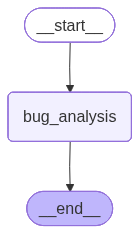

In [6]:
from IPython.display import Image, display
from test_auto.graph.bug_analysis_workflow import build_bug_analysis_graph

graph = build_bug_analysis_graph()
try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    print(graph.get_graph().draw_mermaid())
